<img src="./logo_UTN.svg" align="right" width="150" /> 

#### Teoría de los Circuitos 2

# **Informe de Laboratorio 1**
#### Nahuel Siles

Diseñar un filtro pasaaltos **Chebyshev** que cumpla con la siguiente plantilla:

<img src="./plantilla_tp1.png" /> 

## Análisis y Simulación

1. Obtener el orden del filtro y hallar la función transferencia total. 
2. Obtener la transferencia de la red circuital a implementar.
3. Simulación numérica/simbólica de la función transferencia en Python. 
4. Simulación circuital. Incluya el modelo real del OPAMP.

## Implementación y armado:

1. Disenar el Layout del PCB.
2. Usar conectores, headers o borneras para alimentar el filtro, introducir la señal de entrada, medir la señal de entrada y salida ( test points )  
3. Utilizar un zócalo DIP 14 para colocar el OPAMP.
4. Incluir resistores variables ( presets / trimmer ) o bien resistores fijos con tolerancias del 1%.
5. Agregar capacitores de bypass en la alimentacion del Amplificador. Agregar capacitor electrolítico o poliéster de 1 µF a 100 µF con otro cerámico de 100 nF a 470 nF en paralelo para reducir el ruido de la fuente.

## Medición:

<img src="./forma_de_medicion_tp1.png" /> 

1. Verificar visualmente y con el multímetro que el circuito no tiene cortocircuitos y que los componentes estén correctamente soldados. 
2. Utilice la limitación de corriente de la fuente en algunas decenas de mA. Para ello se debe poner en corto los bornes de + y - a una tensión baja por ejemplo 1 V. De esta manera el equipo entra en modo CC ( corto circuito ) y se puede setear el nivel de corriente.   
3. Setear la tensión de la fuente. Utilice un multímetro para ajustar la tensión de la fuente. Finalmente alimente su circuito.  Tenga en cuenta que la medición mejora para niveles más altos de fuente.
4. Verifique las puntas del osciloscopio. Utilice la señal de prueba tanto en el canal 1 como 2 para ajustar la respuesta temporal visualizada. Verifique el valor de AC y periodo de esta señal de prueba con los medidores del DSO.
5. Calibre una señal senoidal en el generador a un nivel que optimice la medición en la banda de paso de  valor medio nulo con el generador. Tenga en cuenta que el filtro puede generar sobretensiones a la salida.
6. Desenergice el circuito si así estuviera y conecte el integrado. Conecte la alimentación nuevamente y el generador de entrada. Verifique que el DSO tenga señal a la salida. Debe ser de la misma forma ( sin distorsión ) que la entrada con una cierta fase y alguna diferencia de amplitud probablemente.
7. Llegado a este punto está en condiciones de realizar un barrido con frecuencia.

In [26]:
# Módulos numéricos y de funciones científicas
import numpy as np
from scipy import signal as sig
import sympy as sp
from IPython.display import display, Math

# Módulos para los gráficos
import matplotlib as mpl
from matplotlib import pyplot as plt

# Funciones de PyTC2
from pytc2.sistemas_lineales import bodePlot, pzmap, GroupDelay, analyze_sys, tf2sos_analog, pretty_print_SOS
from pytc2.general import print_latex, print_subtitle, a_equal_b_latex_s

#Tamaño de los gráficos
fig_sz_x = 13
fig_sz_y = 7
fig_dpi = 80 # dpi

fig_font_size = 11

mpl.rcParams['figure.figsize'] = (fig_sz_x, fig_sz_y)
mpl.rcParams['figure.dpi'] = fig_dpi
plt.rcParams.update({'font.size':fig_font_size})

### **Análisis y Simulación:**

#### **Función Transferencia**


Como trabajaremos con un filtro pasa altos, primero debemos transformar la plantilla a un pasa bajos para obtener el orden y la función transferencia.

Primeramente normalizamos las frecuencias con  $\Omega_\omega =300Hz$ por lo que las frecuencias quedan de la siguiente manera:

$\omega_{p_n} = \frac{\omega_p}{\omega_p} = 1$
 
$\omega_{s_n} = \frac{\omega_s}{\omega_p} = \frac{f_s}{f_p} = \frac{100Hz}{300Hz} = \frac{1}{3} = 0.33$

Calculamos las frecuencias de la plantilla pasa bajos sabiendo que $\omega_{LP}=\frac {1}{ \omega_{HP} }$:

$ \omega_{P_{LP}} = \frac{1}{\omega_{p_n}} = 1 $

$ \omega_{S_{LP}} = \frac{1}{\omega_{s_n}} = 3 $

Como tenemos la atenuación para esas frecuencias ya contamos con los datos requeridos para calcular el orden del filtro.

$\alpha_{max}=1 dB$

$\alpha_{min}=30 dB$

Comenzamos calculando el valor de $\epsilon^2=10^{\frac {\alpha_{max}}{10}} - 1$

$\epsilon^2=0.2589$

Para el orden iteramos la siguiente expresion hasta llegar a un valor de **n** el cual haga que $\alpha [dB] > \alpha_{min}$

$$
\alpha_{db} = 10*log(1 + \epsilon^2 cosh^2( n*cosh^{-1}(w) ) )
$$

Para $n=3$, $\alpha [dB] = $

Nuestro filtro entonces es de **tercer orden (n=3)**

El polinomio de Chebyshev de tercer orden es el siguiente:
$$
C_3(\omega) = 4\omega^3 - 3\omega
$$

Reemplazamos en la expresión general de la transferencia:
$$
|H(j\omega)|^2 = \frac{1}{1 + \epsilon^2 C_3^2(\omega)}
$$

$$
|H(j\omega)|^2 = \frac{1}{1 + \epsilon^2 (4\omega^3 - 3\omega)^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \xi^2 (16\omega^6 -24\omega^4 + 9\omega^2}
$$

$$
|H(j\omega)|^2 =\frac{1}{1 + \epsilon^2 16\omega^6 -\epsilon^2 24\omega^4 + \epsilon^2 9\omega^2}
$$

$$
|H(j\omega)|^2 =\frac{ \frac{1}{16\epsilon^2} }{\omega^6 -\frac{3}{2}\omega^4 + \frac{9}{16}\omega^2 + \frac{1}{16\epsilon^2}}
$$

Como $\omega = \frac{s}{j}$ nos queda que:

$$
|H(s)|^2 =\frac{ \frac{1}{16\epsilon^2} }{-s^6 -\frac{3}{2}s^4 - \frac{9}{16}s^2 + \frac{1}{16\epsilon^2}}
$$

$$
|H(s)|^2 =\frac{ \frac{1}{16\epsilon^2} }{-s^6 -\frac{3}{2}s^4 - \frac{9}{16}s^2 + \frac{1}{16\epsilon^2}}
$$


Usando la identidad $|H(s)|^2 = H(s).H(-s)$:

$$
|H(s)|^2 =\frac{ \frac{1}{16\epsilon^2} }{-s^6 -\frac{3}{2}s^4 - \frac{9}{16}s^2 + \frac{1}{16\epsilon^2}} = \frac{a}{s^3+s^2b+sc+d}\frac{a}{-s^3+s^2b-sc+d} 
$$

Igualando los coeficientes del denominador y numerador:

$$
a^2=d^2=\frac{1}{16\epsilon^2} \Rightarrow a=d=\frac{1}{4\epsilon} \quad (1)
$$

$$
b^2-2c=-\frac{3}{2} \quad (2)
$$

$$
2bd-c^2= - \frac{9}{16} \quad (3)
$$

Despejamos $c$ de (3):

$$
c=\sqrt{2bd+\frac{9}{16}}
$$

Reemplazamos c en (2):

$$
b^2-2\sqrt{b\frac{1}{2\epsilon}+\frac{9}{16}}=-\frac{3}{2}
$$

$$
b^2+ \frac{3}{2} = \sqrt{b\frac{2}{\epsilon}+\frac{9}{4}}
$$

$$
(b^2+ \frac{3}{2})^2 = b\frac{2}{\epsilon}+\frac{9}{4}
$$

$$
b^4+3b^2+\frac{9}{4}=b\frac{2}{\epsilon}+\frac{9}{4}
$$

$$
b^3+3b-\frac{2}{\epsilon}=0
$$

Nos quedamos con el resultado real $b=0.9883$

Entonces los coeficientes de la función transferencia son:

$a=d=0.4913$

$b=0.9883$

$c=1.2384$

Quedando entonces el prototipo pasabajos:


$$
H(s) = \frac{0.4913}{s^3 + s^2  0.9883 + s  1.2384 + 0.4913}
$$


Antes de aplicar el núcleo de transformación separamos la transferencia en secciones. En nuestro caso, una de segundo orden junto a una de primer orden:

In [28]:
num = [0.4913]
den = np.array([1, 0.9883, 1.2384, 0.4913])

Tfsos = tf2sos_analog(num , den)

print_latex(a_equal_b_latex_s('T_{hp}(s)', pretty_print_SOS(Tfsos, displaystr=False)))

<IPython.core.display.Math object>

Ahora si aplicamos el núcleo de transformación:

$$
s=\frac{1}{s}
$$

$$
T(s) = \frac{0.4942}{ \frac{1}{s} + 0.4942 } . \frac{0.9942}{ \frac{1}{s^2} + \frac{1}{s}0.4941 + 0.9942 }
$$

$$
T(s) = \frac{0.4942}{ \frac{1}{s} + 0.4942 } . \frac{0.9942}{ \frac{1}{s^2} + \frac{1}{s}0.4941 + 0.9942 }
$$

$$
T(s) = \frac{0.4942.s}{ 1 + 0.4942 .s }. \frac{0.9942}{ \frac{  1 + s. 0.4941 + s^2 . 0.9942}{ s^2  } }
$$

$$
T(s) = \frac{0.4942.s}{ 1 + 0.4942 .s }. \frac{0.9942.s^2}{  1 + s. 0.4941 + s^2 . 0.9942 }
$$

Finalmente obtenemos la tranferencia pasa altos de tercer orden:

$$
T(s) = \frac{s}{ s + 2.0234 }. \frac{s^2}{ s^2 + s. 0.497 + 1.0058 }
$$


#### **Simulación de la transferencia**

Simularemos la transferencia obtenida mediente python:

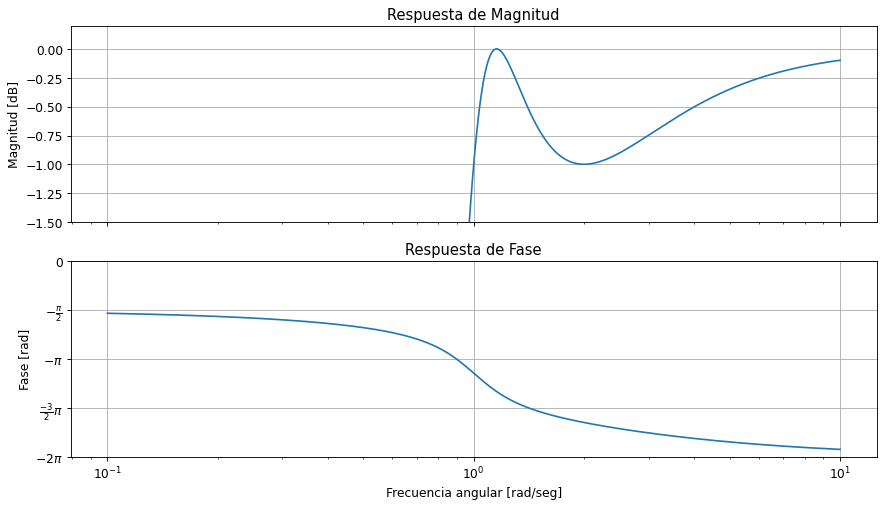

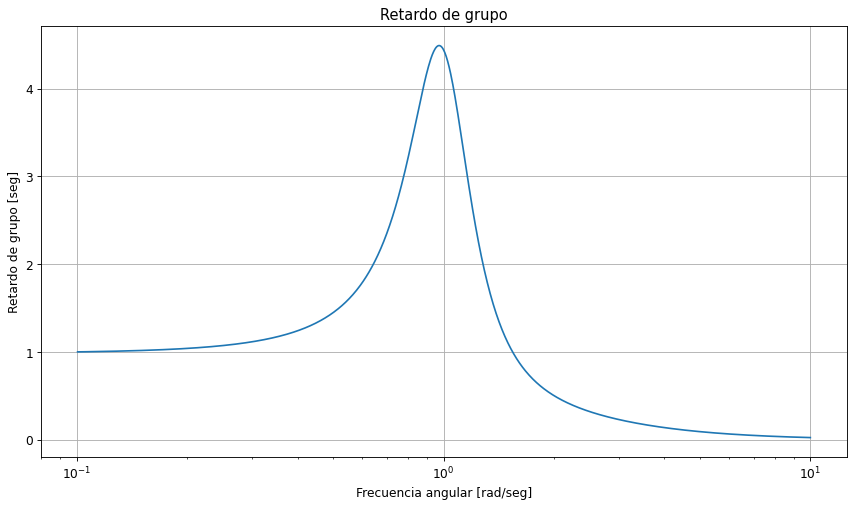

In [50]:
numPrimer = np.array([1, 0])
denPrimer = np.array([1, 2.0234])

numSegundo = np.array([1, 0, 0])
denSegundo = np.array([1, 0.497, 1.0058])

Ts1 = sig.TransferFunction(numPrimer , denPrimer)
Ts2 = sig.TransferFunction(numSegundo , denSegundo)

num = np.polymul( Ts1.num , Ts2.num )
den = np.polymul( Ts1.den , Ts2.den )

Ts = sig.TransferFunction(num,den)

_ , axes = bodePlot(Ts)
_ , axes2 = GroupDelay(Ts)

axes[0].set_ylim(-1.5,0.2)
plt.show()

Vemos claramente como la función oscila en la banda de paso hasta $-1dB$

Para estar seguros comprobamos cuanto vale la función en las frecuencias de corte:

In [49]:
_, resp1 = sig.freqresp(Ts, [1])
display(Math(r'\alpha_{wp_n}(1) = ' +  sp.latex(20*np.log10(abs(resp1[0]))) ))

_, resp2 = sig.freqresp(Ts, [0.33])
display(Math(r'\alpha_{wp_s}(0.33) = ' +  sp.latex(20*np.log10(abs(resp2[0]))) ))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

Los valores obtenidos cumplen con la plantilla, por lo que la función transferencia hallada es la correcta.

#### **Simulación circuital**

Para la implementación circuital utilizamos la topología ***Ackerberg-Mossberg*** para la sección de segundo orden junto a un RC para la sección de primer orden. 

La sección de segundo orden la implementamos mediante un circuito activo Voltage Feedforward, el cual obtenemos del Schaumann:

<img src = "RedVF.PNG"/>

Los valores de las constantes vienen definidas por la siguiente tabla:

<img src = "TablaVF.PNG"/>

La función transferencia general del circuito es:

$$
T_2(s)=- \frac{  a.s^2 + s.w_0.(k-b) +c.w_0^2  }{  s^2 + s.\frac{w_0}{Q} + w_0^2 }
$$

Donde $w_0= \frac {1}{RC}$

Tomando los valores para un pasa altos de la tabla, la función queda:

$$
T_2(s)=- \frac{  a.s^2  }{  s^2 + s.\frac{w_0}{Q} + w_0^2 }
$$

Quedando el circuito entonces sin las resistencias: $\frac{R}{k}$, $\frac{R}{b}$ y $\frac{R}{c}$

Igualando los coeficientes de nuestro pasa altos con los del *Ackerberg-Mossberg*:

$a=1$

$\frac{w_0}{Q} = 0.497$

$w_0^2 = (\frac{1}{RC})^2 = 1.0058$

Si $C=1$ entonces:

$$
R = \frac{1}{\sqrt{1.0058}.C} \Rightarrow R = 0.9971
$$ 

$$
\frac{w_0}{Q} = 0.497
$$

$$
\frac{ \sqrt{1.0058} }{Q} = 0.497
$$

$$
Q = \frac{ \sqrt{1.0058} }{0.497}
$$

$$ Q = 2.01789 $$

Para la secicon de primer orden utilizamos un RC simple:

<img src="RedRC.PNG" width="200"/>

Su transferencia es: 

$$
T_1(s) = \frac{s}{s + \frac{1}{RC} }
$$

Si $C=1 \Rightarrow R=0.4942$ 

Entonces los valores de los componentes del circuito completo son:

Primer Orden:

$R=0.4942$

$C=1$

Segundo Orden:

$C = 1$

$R = 0.99711$

$R_A = 1$ (Resistencias del inversor)

$Q = 2.01789$

Todo normalizado en $w=1$. Para desnormalizar los componentes utilizamos la norma de frecuencia $\Omega_w = 2\pi 300$ para obtener la norma de impedancia $\Omega_z$. Para ello utilizaremos capacitores de 100n

$$
C = \frac{c_n}{\Omega_w . \Omega_z}
$$

$$
\Omega_z = \frac{c_n}{\Omega_w . C}
$$

$$
\Omega_z = 5305.164
$$

Entonces los componentes desnormalizados son:

Primer Orden:

$R = 2.621K  \Rightarrow R_{comercial} = 2.7K$

$C = 100nF$

Segundo Orden:

$C = 100nF$

$R = 5.289K  \Rightarrow R_{comercial} = 5.6K$

$R_A = 10K$ (Resistencias del inversor)

$Q = 2.01789$

A continuación mostramos la simulación con los valores no comerciales de los componentes:

<img src="sRedHP.PNG" />
<img src="sRedHP_Simulacion.PNG">

Vemos tambien la simulación con los componentes reales asi como tambien con el operacional real, en nuestro caso, el LM358n

<img src="rRedHP.PNG" />
<img src="rRedHP_Simulacion.PNG">

Al simular el circuito con el opamp real, vimos que habia atenuación de hasta 1dB en la banda de paso. Para solucionar este error reemplazamos la resistencia de salida por una de 3K.

### **Implementación y Armado:**

Para la implementación del filtro diseñamos el siguiente PCB:

<img src="PCB.PNG"/>

En dicho diseño utilizamos cuatro presets multivuelta. Tres de ellos en la sección de segundo orden y uno en la de primer orden. En la seccion de primer orden colocamos dos para lograr valores iguales de $R$ y $R_A$ mientras que el otro fue puesto para lograr un valor preciso de $R*Q$. En la sección de primer orden lo colocamos como al resistencia de salida ya que modificando este valor, logramos una menor atenuación en la banda de paso.

Incluimos pines en el diseño destinados a la alimentación de los amplificadores operacionales, la alimentación del filtro mediante un generador de señales y la medición de las señales de entrada y salida.

Colocamos en paralelo a la alimentación de los opamps dos capacitores de bypass de $0.1uF$ (cerámico) y $10uF$ (electrolítico)

### **Medición y Resultados**

La placa armada queda de la siguiente manerea:

<img src="Placa.PNG"/>

Para las mediciones utilizamos los siguientes instrumentos:

• Osciloscopio

• Generador de señales

• 2 Fuentes DC

• Analizador de espectro

Con las fuentes armamos una fuente partida para alimentar los opamp con $+15V$ y $-15V$, con el generador de señales alimentamos el circuito con una senoidal de $12V$ pico a pico, y con el osciloscopio observamos simultaneamente la forma de onda de la señal de entrada y salida. Una vez corroborado el correcto funcionamiento del filtro y tomadas las mediciones utilizamos un analizador de espectro para hacer un barrido en frecuencia y observar la forma del filtro pasa altos.

Utilizando el generador de señales variamos la frecuencia de la señal de entrada y medimos la tensión de salida para comprobar la efectividad del filtro:

|F[Hz]|$V_{output}[V]$|$V_{output}[dB]$|
|:---:|:-------------:|:--------------:|
|100  |0.16           |-31.48          |
|140  |0.5            |-21.58          |
|180  |1.1            |-14.73          |
|220  |2.4            |-7.958          |
|260  |4.64           |-2.232          |
|300  |6              |0               |
|310  |6.1            |0.1435          |
|320  |6.16           |0.2285          |
|330  |6.1            |0.1435          |
|350  |6              |0               |
|400  |5.76           |-0.3545         |
|570  |5.36           |-0.9797         |
|590  |5.36           |-0.9797         |
|600  |5.3            |-1.077          |
|610  |5.35           |-0.9959         |
|630  |5.35           |-0.9959         |
|650  |5.36           |-0.9797         |
|700  |5.44           |-0.8510         |
|1K   |5.6            |-0.5992         |
|2K   |5.7            |-0.4455         |

Observamos que cumple la atenuación minima y maxima en $100 Hz$ y $300Hz$ respectivamente. Tambien notamos que en la banda de paso hay atenuación y amplificación. Esto no deberia de pasar, pero es tolerable debido a que los valores de los componentes no son fijos. 

Al graficar la salida del filtro en dB nos queda:

<img src="GraficoDatosMedidos.png"/>

El gráfico que nos brindó el analizador de espectro:

<img src="GraficoAnalizador.jpeg"/>

Comparando ambos podemos afirmar que los datos medidos fueron correctos y el filtro actua como un pasa altos.

Para graficar la fase necesitamos calcular sus valores utilizando la siguiente expresión:

$$
\phi = 2\pi. f.\Delta t
$$

Entonces:

|F[Hz]|$\Delta T$|$Fase[rad]$|
|:---:|:--------:|:------------:|
|100  |2         |72            |
|140  |1.16      |58.464        |
|180  |0.64      |41.472        |
|220  |0.3       |23.76         |
|260  |0.12      |11.232        |
|300  |-0.43     |-46.4         |
|310  |-0.48     |-53.568       |
|320  |-0.51     |-58.752       |
|330  |-0.54     |-64.152       |
|350  |-0.6      |-75.6         |
|400  |-0.67     |-96.48        |
|570  |-0.58     |-119.016      |
|590  |-0.56     |-118.944      |
|600  |-0.57     |-123.12       |
|610  |-0.56     |-122.976      |
|630  |-0.55     |-124.74       |
|650  |-0.54     |-126.36       |
|700  |-0.52     |-131.04       |
|1K   |-0.4      |-144          |
|2K   |-0.224    |-161.28       |

El gráfico de la fase mediante nuestros datos:

<img src="FaseDatosMedidos.PNG"/>

La fase que nos brindo el analizador de espectro:

<img src="FaseAnalizador.jpeg"/>

Comparando ambos vemos un comportamiento similar sin tomar en cuenta que la fase del analizador se encuentra medida en grados.

Para obtener el gráfico del retardo de grupo aplicamos la siguiente expresión:

$$
\tau_g = \frac{ \phi_{i+1} - \phi_i }{ f_{i+1} - f_i }
$$

Entonces nos queda:

|F[Hz]|$Fase [rad]$|$D [mseg]$|
|:---:|:--------:|:------------:|
|100  |1.2566	 |0.93981       |
|140  |	1.0204	 |1.18013       |
|180  |	0.7238	 |1.22987       |
|220  |	0.4147	 |0.87018       |
|260  |	0.196	 |4.00474       |
|300  |	-0.8105	 |1.97989       |
|310  |	-0.9349	 |1.44035       |
|320  |	-1.0254	 |1.50083       |
|330  |	-1.1197	 |1.58996       |
|350  |	-1.3195	 |1.15992       |
|400  |	-1.6839	 |0.36821       |
|570  |	-2.0772	 |-0.00955      |
|590  |	-2.076	 |1.15865       |
|600  |	-2.1488	 |-0.03979      |
|610  |	-2.1463	 |0.2451        |
|630  |	-2.1771	 |0.2252        |
|650  |	-2.2054	 |0.26006       |
|700  |	-2.2871	 |0.12          |
|1000 |	-2.5133	 |0.048         |
|2000 |	-2.8149	 |0.224         |

<img src="Retardo.PNG"/>

Vemos que el retardo tiene valores similares al simulado.

### **Conclusión**

Como conclusión podemos afirmar que el filtro realizado cumple con las especificaciones pedidas por lo que el desarrollo y armado del circuito fueron exitosamente realizados. Se podrían obtener mejores resultados si hubieramos utilizados unicamente presets en la placa, ya que garantizariamos los valores utilizados en la simulación.